In [10]:
import joblib
import requests
import numpy as np
import pandas as pd
import rasterio
from rasterio.merge import merge
from scipy.ndimage import sobel
import matplotlib.pyplot as plt

In [11]:
src_north = rasterio.open("bng_north.tif")
src_south = rasterio.open("bng_south.tif")
nodata_val = src_north.nodata

elevation_matrix, elevation_transform = merge([src_north, src_south])
target_crs = src_north.crs.to_string()
target_height = elevation_matrix.shape[1]
target_width = elevation_matrix.shape[2]
src_north.close()
src_south.close()

elevation_grid = elevation_matrix[0].astype(np.float32)
if nodata_val is not None:
    elevation_grid[elevation_grid == nodata_val] = np.nan

slope_x = sobel(elevation_grid, axis=1)
slope_y = sobel(elevation_grid, axis=0)
slope = np.hypot(slope_x, slope_y)

print(f"Terrain loaded: {target_height}x{target_width}")

Terrain loaded: 7200x3600


In [12]:
rf_model = joblib.load('flood_model.pkl')
print("Model loaded successfully")

Model loaded successfully


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [13]:
def get_bengaluru_forecast():
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": 12.9716,
        "longitude": 77.5946,
        "daily": "precipitation_sum",
        "timezone": "Asia/Kolkata",
        "forecast_days": 3
    }
    data = requests.get(url, params=params).json()
    daily_rain = data['daily']['precipitation_sum']
    dates = data['daily']['time']

    total = sum(daily_rain)
    mean = np.mean(daily_rain)
    maximum = max(daily_rain)

    print("===== LIVE FORECAST (Next 3 Days) =====")
    for date, rain in zip(dates, daily_rain):
        print(f"{date}: {rain:.1f}mm")
    print(f"\nTotal: {total:.1f}mm | Mean: {mean:.1f}mm | Peak: {maximum:.1f}mm")
    return total, mean, maximum

total, mean, maximum = get_bengaluru_forecast()

===== LIVE FORECAST (Next 3 Days) =====
2026-05-21: 2.7mm
2026-05-22: 7.1mm
2026-05-23: 4.2mm

Total: 14.0mm | Mean: 4.7mm | Peak: 7.1mm


In [14]:
forecast_grid = pd.DataFrame({
    'elevation':      elevation_grid.flatten(),
    'max_rainfall':   maximum,
    'mean_rainfall':  mean,
    'total_rainfall': total,
    'slope':          slope.flatten()
})

flood_probability = rf_model.predict_proba(forecast_grid)[:, 1]
flood_risk_map = flood_probability.reshape(target_height, target_width)
print("Prediction complete")

Prediction complete


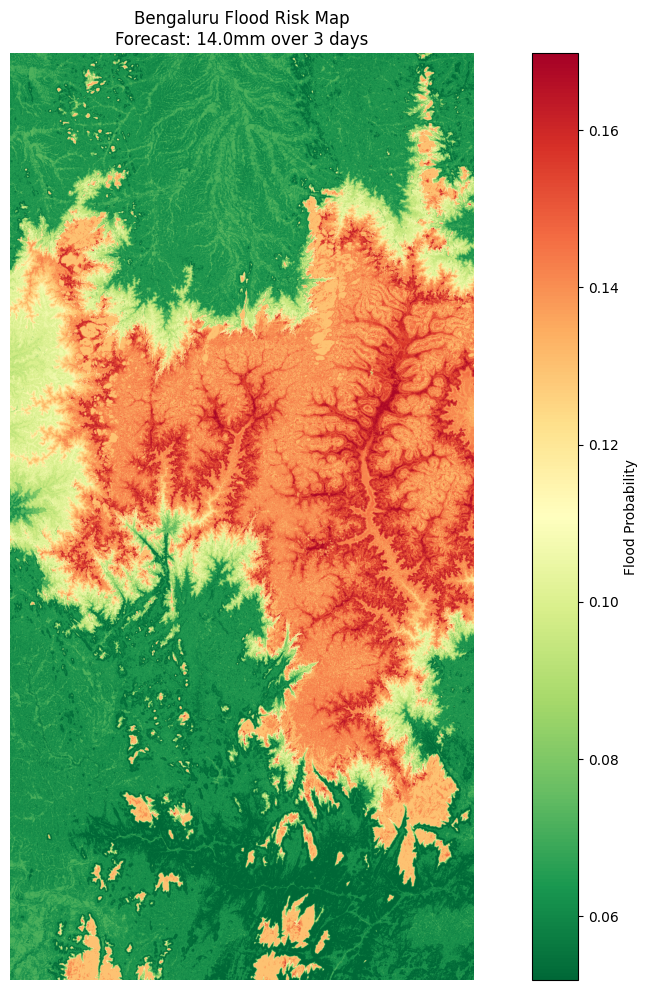

In [15]:
plt.figure(figsize=(12, 10))
plt.imshow(flood_risk_map, cmap='RdYlGn_r')
plt.colorbar(label='Flood Probability')
plt.title(f'Bengaluru Flood Risk Map\nForecast: {total:.1f}mm over 3 days')
plt.axis('off')
plt.tight_layout()
plt.savefig('flood_risk_forecast.png', dpi=150)
plt.show()

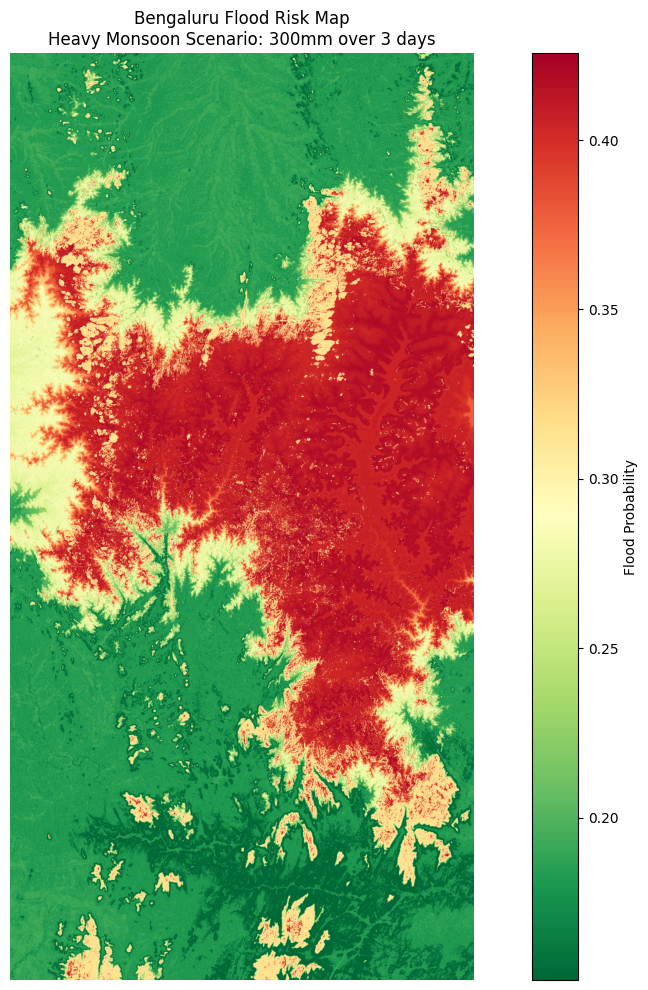

In [16]:
forecast_grid_heavy = pd.DataFrame({
    'elevation':      elevation_grid.flatten(),
    'max_rainfall':   150,
    'mean_rainfall':  50,
    'total_rainfall': 300,
    'slope':          slope.flatten()
})

flood_probability_heavy = rf_model.predict_proba(forecast_grid_heavy)[:, 1]
flood_risk_heavy = flood_probability_heavy.reshape(target_height, target_width)

plt.figure(figsize=(12, 10))
plt.imshow(flood_risk_heavy, cmap='RdYlGn_r')
plt.colorbar(label='Flood Probability')
plt.title('Bengaluru Flood Risk Map\nHeavy Monsoon Scenario: 300mm over 3 days')
plt.axis('off')
plt.tight_layout()
plt.savefig('flood_risk_heavy.png', dpi=150)
plt.show()

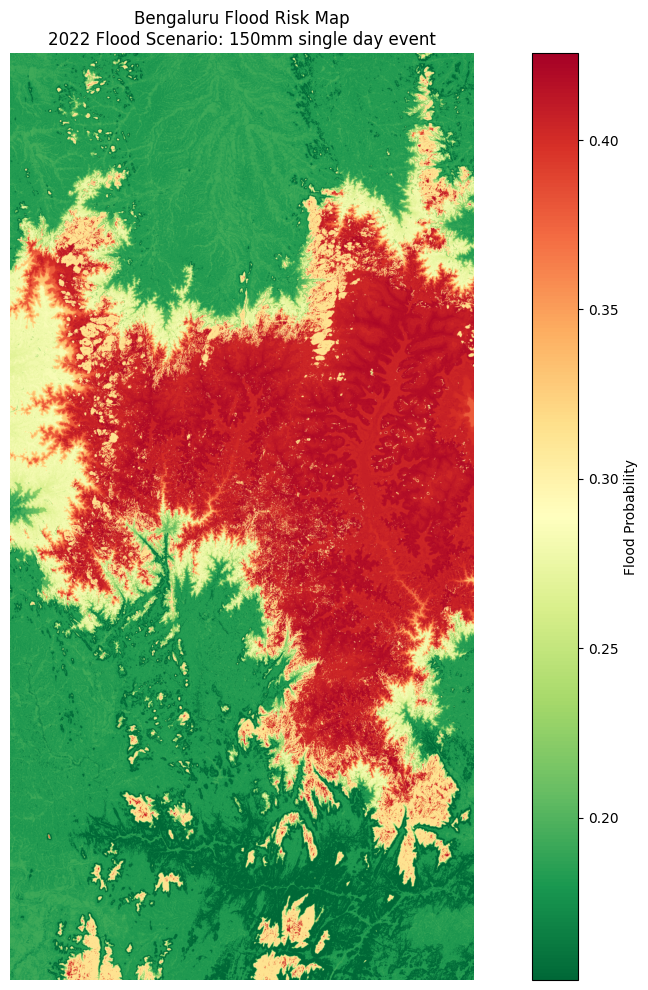

In [17]:
forecast_grid_2022 = pd.DataFrame({
    'elevation':      elevation_grid.flatten(),
    'max_rainfall':   150,
    'mean_rainfall':  30,
    'total_rainfall': 150,
    'slope':          slope.flatten()
})

flood_probability_2022 = rf_model.predict_proba(forecast_grid_2022)[:, 1]
flood_risk_2022 = flood_probability_2022.reshape(target_height, target_width)

plt.figure(figsize=(12, 10))
plt.imshow(flood_risk_2022, cmap='RdYlGn_r')
plt.colorbar(label='Flood Probability')
plt.title('Bengaluru Flood Risk Map\n2022 Flood Scenario: 150mm single day event')
plt.axis('off')
plt.tight_layout()
plt.savefig('flood_risk_2022.png', dpi=150)
plt.show()

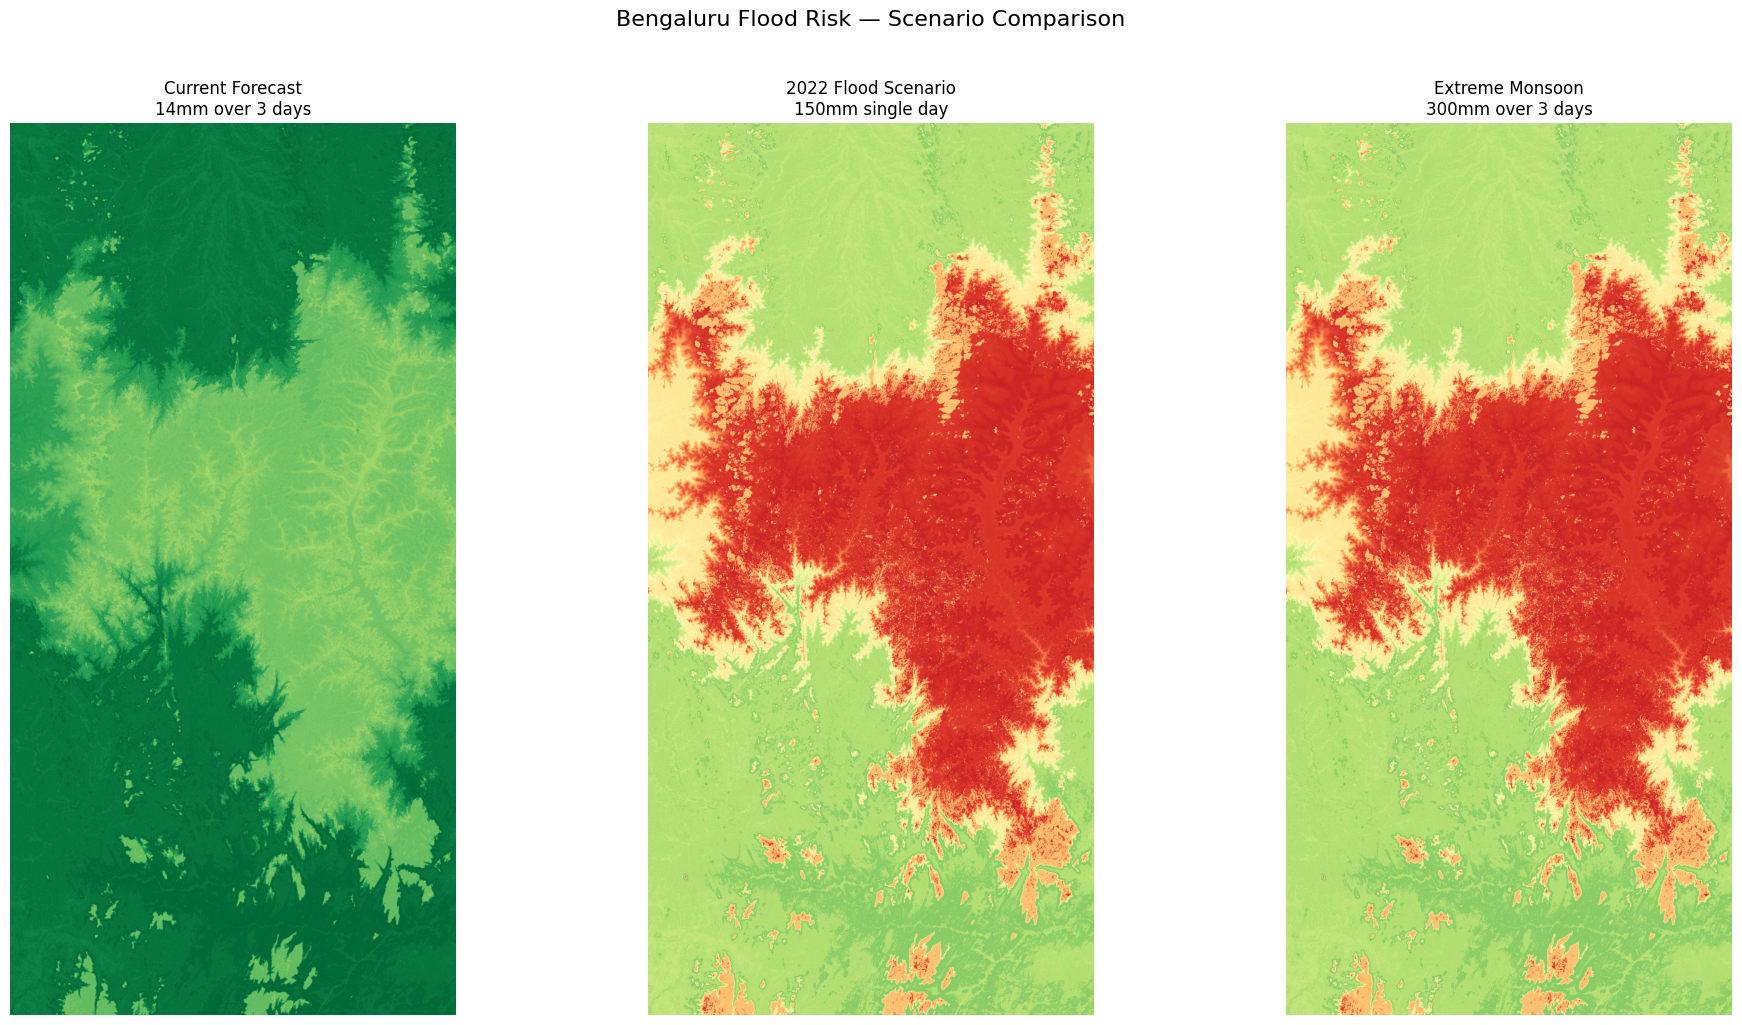

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 10))

axes[0].imshow(flood_risk_map, cmap='RdYlGn_r', vmin=0.05, vmax=0.45)
axes[0].set_title('Current Forecast\n14mm over 3 days', fontsize=12)
axes[0].axis('off')

axes[1].imshow(flood_risk_2022, cmap='RdYlGn_r', vmin=0.05, vmax=0.45)
axes[1].set_title('2022 Flood Scenario\n150mm single day', fontsize=12)
axes[1].axis('off')

axes[2].imshow(flood_risk_heavy, cmap='RdYlGn_r', vmin=0.05, vmax=0.45)
axes[2].set_title('Extreme Monsoon\n300mm over 3 days', fontsize=12)
axes[2].axis('off')

plt.suptitle('Bengaluru Flood Risk — Scenario Comparison', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('scenario_comparison.png', dpi=150, bbox_inches='tight')
plt.show()